# Perception Stack - Notebook 01: LLaVA Baseline Inference

This notebook runs the baseline condition of the Perception Stack evaluation.
LLaVA-1.5 7B is given the last frame of each clip and an object identity list
derived from the CLEVRER annotation file. No physical context from the pipeline
is provided. This establishes the image-only baseline against which the enhanced
pipeline is compared.

## Steps
- Mount Google Drive and define all constants and paths
- Install dependencies and load LLaVA-1.5 7B with 4-bit NF4 quantization
- Load selected clip IDs, QA JSON, and verify keyframes exist on Drive
- Define the answer parser (3-tier extraction strategy with vocabulary normalization)
- Define the scorer (exact match for descriptive and predictive; per-option, per-question,
  and F1 for explanatory and counterfactual)
- Run inference loop across all 70 clips with per-clip checkpointing
- Aggregate scores and print the summary results table
- Save summary CSV to the analysis folder on Drive
- Generate and save all report figures: per-question accuracy, per-option and F1,
  parse tier distribution, reasoning coverage, descriptive subtype accuracy,
  and F1 distribution histogram

---
> **Note:** This notebook is natively developed and run on Google Colab (A100 GPU recommended).
> If it does not render correctly in your viewer, please open it directly on Colab:
> [Open in Google Colab](<https://colab.research.google.com/drive/10BdajiR_yB6bTzpjz_m3Qmb-_3d88wJ4?usp=sharing>)

---
## Cell 1 - Mount Drive + define all paths and constants:

In [2]:
# ── Cell 1 — Mount Drive + Constants ──────────────────────────────────────────
from google.colab import drive, userdata
drive.mount('/content/drive')

import os

# ── Constants ──────────────────────────────────────────────────────────────────
NO_CLIPS   = 70
MODEL_ID   = "llava-hf/llava-1.5-7b-hf"
HF_TOKEN   = userdata.get('HF_TOKEN')

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE         = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"
CLIPS_DIR    = os.path.join(BASE, "data/clips")
QA_PATH      = os.path.join(BASE, "data/qa/validation_qa.json")
KF_DIR       = os.path.join(BASE, "data/keyframes")
ANN_DIR      = os.path.join(BASE, "data/annotations")
ID_PATH      = os.path.join(BASE, "data/selected_clip_ids.json")
OUT_DIR      = os.path.join(BASE, "outputs/stage4_llava")
FIGURES_DIR  = os.path.join(BASE, "figures")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Drive mounted.")
print(f"Working with up to {NO_CLIPS} clips.")

Mounted at /content/drive
Drive mounted.
Working with up to 70 clips.


In [3]:
# ── CLEAR: Delete all baseline outputs from NB01 ───────────────────────────
import os, shutil

BASE = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"

# Clear baseline JSONs
llava_dir = os.path.join(BASE, "outputs/stage4_llava")
deleted = 0
for f in os.listdir(llava_dir):
    if f.startswith("baseline_") and f.endswith(".json"):
        os.remove(os.path.join(llava_dir, f))
        deleted += 1
print(f"Deleted {deleted} baseline JSONs")

# Clear NB01 figures
fig_dir = os.path.join(BASE, "figures")
deleted_figs = 0
for f in os.listdir(fig_dir):
    if f.startswith("01_"):
        os.remove(os.path.join(fig_dir, f))
        deleted_figs += 1
print(f"Deleted {deleted_figs} NB01 figures")

# Clear baseline CSV
csv_path = os.path.join(BASE, "analysis/baseline_summary.csv")
if os.path.exists(csv_path):
    os.remove(csv_path)
    print("Deleted baseline_summary.csv")

print("NB01 slate cleared.")

Deleted 2 baseline JSONs
Deleted 8 NB01 figures
Deleted baseline_summary.csv
NB01 slate cleared.


---
## Cell 2 - Install dependencies + load model

In [4]:
# ── Cell 2 — Install Dependencies + Load Model ────────────────────────────────
# bitsandbytes: 4-bit quantization
# transformers + accelerate: LLaVA model loading
# Pillow: image loading

!pip install -q bitsandbytes transformers accelerate pillow

import torch
from transformers import LlavaForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

# ── 4-bit quantization config ──────────────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# ── Load model + processor ─────────────────────────────────────────────────────
print("Loading model... (takes ~2 min on first run)")
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    token=HF_TOKEN,
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
model.eval()

print(f"Model loaded on: {next(model.parameters()).device}")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.9 MB/s eta 0:00:00
Loading model... (takes ~2 min on first run)


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

Model loaded on: cuda:0
VRAM used: 4.06 GB


---
## Cell 3 - Load clip IDs, QA JSON, and keyframes:

In [5]:
# ── Cell 3 — Load Clip IDs, QA JSON, Keyframes ────────────────────────────────
import json
from PIL import Image

# ── Load selected clip IDs ─────────────────────────────────────────────────────
with open(ID_PATH, 'r') as f:
    ALL_SELECTED_IDS = json.load(f)

# Use only NO_CLIPS from the full selected list
SELECTED_IDS = ALL_SELECTED_IDS[:NO_CLIPS]
print(f"Total IDs on Drive : {len(ALL_SELECTED_IDS)}")
print(f"Using this run     : {len(SELECTED_IDS)}")

# ── Load full QA JSON, index by scene_index ────────────────────────────────────
with open(QA_PATH, 'r') as f:
    all_qa = json.load(f)
qa_by_id = {entry['scene_index']: entry for entry in all_qa}
print(f"QA entries loaded  : {len(qa_by_id)}")

# ── Verify keyframes exist for all selected clips ──────────────────────────────
missing_kf = []
for vid_id in SELECTED_IDS:
    kf_path = os.path.join(KF_DIR, f"frame_{vid_id:05d}.jpg")
    if not os.path.exists(kf_path):
        missing_kf.append(vid_id)

if missing_kf:
    print(f"WARNING: Missing keyframes for {len(missing_kf)} clips: {missing_kf}")
    print("Run Notebook 00 first to extract keyframes.")
else:
    print(f"All {len(SELECTED_IDS)} keyframes found on Drive.")

Total IDs on Drive : 70
Using this run     : 70
QA entries loaded  : 5000
All 70 keyframes found on Drive.


---
## Cell 4 - Sanity Check:

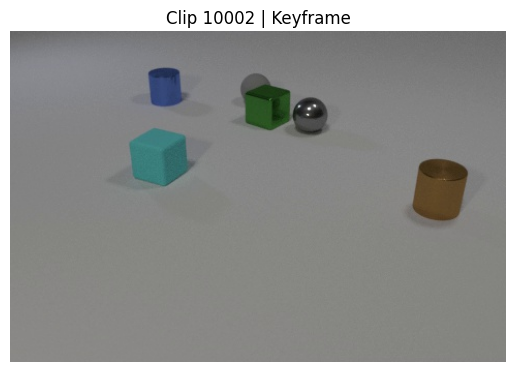

── Full prompt seen by model ──
USER: <image>
You are analyzing a single frame from a short video clip. The video depicts a physical scene with objects that may interact over time. Answer the following question based on what you can observe.

Question: How many green objects are moving when the rubber sphere enters the scene?

You must respond using exactly this format and no other format:
ANSWER: [single word or number]
REASONING: [2 sentences max explaining your observation]
Remember: use the ANSWER, REASONING format exactly.
ANSWER:

Clip ID       : 10002
Question type : descriptive
Question      : How many green objects are moving when the rubber sphere enters the scene?
Ground truth  : 1

Raw output:
1
REASONING: There is only one green object moving when the rubber sphere enters the scene.


In [6]:
# ── Cell 4 — Sanity Check — Single Image + Question ───────────────────────────
# Runs one real question through the full prompt pipeline.
# Verifies model, processor, image loading, and output format all work.

from PIL import Image
import matplotlib.pyplot as plt

# ── Pick first clip and its first question ─────────────────────────────────────
test_id    = SELECTED_IDS[1]
test_entry = qa_by_id[test_id]
test_q     = test_entry['questions'][1] # <----------------------------------------------
kf_path    = os.path.join(KF_DIR, f"frame_{test_id:05d}.jpg")

# ── Load keyframe ──────────────────────────────────────────────────────────────
image = Image.open(kf_path).convert("RGB")
plt.imshow(image)
plt.title(f"Clip {test_id} | Keyframe")
plt.axis('off')
plt.show()
plt.close()

# ── Build prompt ───────────────────────────────────────────────────────────────
question_text = test_q['question']
q_type        = test_q['question_type']

if q_type == 'descriptive':
    answer_format = "ANSWER: [single word or number]"
    prompt_body = (
        f"Question: {question_text}\n\n"
        f"You must respond using exactly this format and no other format:\n"
        f"{answer_format}\n"
        f"REASONING: [2 sentences max explaining your observation]"
        # f"REASONING: [Think step-by-step and describe your reasoning in 2 sentences maximum]"
    )
else:
    choices     = test_q.get('choices', [])
    choice_text = "\n".join(
        f"{chr(97+i)}) {c['choice']}" for i, c in enumerate(choices)
    )

    if q_type == 'predictive':
        select_instr  = "Answer with only the single correct letter."
        answer_format = "ANSWER: [single letter only, e.g. a]"
    elif q_type in ('explanatory', 'counterfactual'):
        select_instr  = "There may be more than one correct answer, or none."
        answer_format = "ANSWER: [one or more letters comma-separated e.g. a, b -- or 'None' if none apply]"

    prompt_body = (
        f"Question: {question_text}\n\n"
        f"{choice_text}\n\n"
        f"{select_instr}\n"
        f"You must respond using exactly this format and no other format:\n"
        f"{answer_format}\n"
        f"REASONING: [2 sentences max explaining your observation]"
        # f"REASONING: [Think step-by-step and describe your reasoning in 2 sentences maximum]"
    )

full_prompt = (
    f"USER: <image>\n"
    f"You are analyzing a single frame from a short video clip. "
    f"The video depicts a physical scene with objects that may interact over time. "
    f"Answer the following question based on what you can observe.\n\n"
    f"{prompt_body}\n"
    f"Remember: use the ANSWER, REASONING format exactly.\n"
    f"ANSWER:"
)

print("── Full prompt seen by model ──")
print(full_prompt)
print()

# ── Run inference ──────────────────────────────────────────────────────────────
inputs = processor(text=full_prompt, images=image, return_tensors="pt").to("cuda")

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

raw_output = processor.decode(output_ids[0], skip_special_tokens=True)
# Strip the prompt from the output
response = raw_output.split("ANSWER:")[-1].strip()

# ── Print results ──────────────────────────────────────────────────────────────
print(f"Clip ID       : {test_id}")
print(f"Question type : {q_type}")
print(f"Question      : {question_text}")
if q_type != 'descriptive':
    for i, c in enumerate(choices):
        print(f"  {chr(97+i)}) {c['choice']} [{c['answer']}]")
else:
    print(f"Ground truth  : {test_q.get('answer', 'N/A')}")
print(f"\nRaw output:\n{response}")

In [7]:
raw_output

'USER:  \nYou are analyzing a single frame from a short video clip. The video depicts a physical scene with objects that may interact over time. Answer the following question based on what you can observe.\n\nQuestion: How many green objects are moving when the rubber sphere enters the scene?\n\nYou must respond using exactly this format and no other format:\nANSWER: [single word or number]\nREASONING: [2 sentences max explaining your observation]\nRemember: use the ANSWER, REASONING format exactly.\nANSWER: 1\nREASONING: There is only one green object moving when the rubber sphere enters the scene.'

---
## Cell 5 - Answer Parser:

In [9]:
# ── Cell 5 — Answer Parser ─────────────────────────────────────────────────────
import re

# ── Vocabulary normalization map ───────────────────────────────────────────────
VOCAB_NORM = {
    # shapes
    'round'       : 'sphere',
    'circular'    : 'sphere',
    'ball'        : 'sphere',
    'square'      : 'cube',
    'rectangular' : 'cube',
    'box'         : 'cube',
    'cylindrical' : 'cylinder',
    # materials
    'metallic'    : 'metal',
    'shiny'       : 'metal',
    'rubbery'     : 'rubber',
    # existence
    'yeah'        : 'yes',
    'yep'         : 'yes',
    'nope'        : 'no',
}

VALID_LETTERS = set('abcd')

def normalize_descriptive(raw):
    """Lowercase, strip punctuation, apply vocab normalization."""
    token = raw.strip().lower().rstrip('.,!?')
    return VOCAB_NORM.get(token, token)

def extract_letters(text):
    """Extract valid choice letters (a-d) from text, return sorted list."""
    found = re.findall(r'\b([a-d])\b', text.lower())
    return sorted(set(found)) if found else []

def parse_response(raw_output, q_type):
    """
    Parse raw model output into answer and reasoning.
    Returns dict with keys: parsed_answer, reasoning, parse_tier, raw_output

    parsed_answer:
      - descriptive       : normalized string
      - predictive        : single letter string or ''
      - explanatory/cf    : sorted list of letters, or ['none'], or []
    """
    # ── Split ANSWER and REASONING fields ──────────────────────────────────────
    reasoning = ''
    if 'REASONING:' in raw_output:
        parts       = raw_output.split('REASONING:', 1)
        answer_part = parts[0]
        reasoning   = parts[1].strip()
    else:
        answer_part = raw_output

    # ── Extract raw answer token ───────────────────────────────────────────────
    if 'ANSWER:' in answer_part:
        raw_answer = answer_part.split('ANSWER:', 1)[1].strip().split('\n')[0].strip()
    else:
        raw_answer = answer_part.strip().split('\n')[0].strip()

    # ── First line only -- used for tier 2 fallback ────────────────────────────
    first_line = raw_output.strip().split('\n')[0]

    # ── Parse by question type ─────────────────────────────────────────────────
    if q_type == 'descriptive':
        # Tier 1: clean extraction from answer field
        if raw_answer:
            parsed = normalize_descriptive(raw_answer.split()[0])
            tier   = 1
        # Tier 2: first word from first line
        elif first_line.strip():
            parsed = normalize_descriptive(first_line.strip().split()[0])
            tier   = 2
        # Tier 4: fallback
        else:
            parsed = ''
            tier   = 4

    elif q_type == 'predictive':
        # Tier 1: clean single letter from answer field
        if raw_answer and raw_answer[0].lower() in VALID_LETTERS:
            parsed = raw_answer[0].lower()
            tier   = 1
        # Tier 2: scan first line only for first valid letter
        else:
            letters = extract_letters(first_line)
            if letters:
                parsed = letters[0]
                tier   = 2
            # Tier 4: fallback
            else:
                parsed = ''
                tier   = 4

    elif q_type in ('explanatory', 'counterfactual'):
        # Check for explicit 'none' in answer field
        if raw_answer.strip().lower() == 'none':
            parsed = ['none']
            tier   = 1
        # Tier 1: clean letter extraction from answer field
        elif raw_answer:
            letters = extract_letters(raw_answer)
            if letters:
                parsed = letters
                tier   = 1
            # Tier 2: scan first line only
            else:
                letters = extract_letters(first_line)
                if letters:
                    parsed = letters
                    tier   = 2
                # Tier 4: fallback
                else:
                    parsed = []
                    tier   = 4
        # Tier 4: fallback
        else:
            parsed = []
            tier   = 4

    return {
        'parsed_answer' : parsed,
        'reasoning'     : reasoning,
        'parse_tier'    : tier,
        'raw_output'    : raw_output
    }

print("Parser defined.")

Parser defined.


In [10]:
# ── Quick sanity check on parser ───────────────────────────────────────────────
test_cases = [
    ('ANSWER: No\nREASONING: No cyan objects visible.',         'descriptive'),
    ('ANSWER: a',                                               'predictive'),
    ('b, the cylinder collides with the cube',                  'predictive'),
    ('ANSWER: a, b\nREASONING: Both are responsible.',         'explanatory'),
    ('ANSWER: None',                                            'explanatory'),
    ('ANSWER: round\nREASONING: It looks circular.',           'descriptive'),
    ('ANSWER: a\nREASONING: The cube collides with a sphere.', 'predictive'),
    ('ANSWER: a, c\nREASONING: Both b and d are wrong.',       'counterfactual'),
]

print(f"\n{'Raw output':<50} {'Type':<15} {'Parsed':<15} {'Tier':<5} {'Reasoning'}")
print('─' * 110)
for raw, qtype in test_cases:
    result = parse_response(raw, qtype)
    print(f"{repr(raw):<50} {qtype:<15} {str(result['parsed_answer']):<15} "
          f"{result['parse_tier']:<5} {result['reasoning'][:30]}")


Raw output                                         Type            Parsed          Tier  Reasoning
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
'ANSWER: No\nREASONING: No cyan objects visible.'  descriptive     no              1     No cyan objects visible.
'ANSWER: a'                                        predictive      a               1     
'b, the cylinder collides with the cube'           predictive      b               1     
'ANSWER: a, b\nREASONING: Both are responsible.'   explanatory     ['a', 'b']      1     Both are responsible.
'ANSWER: None'                                     explanatory     ['none']        1     
'ANSWER: round\nREASONING: It looks circular.'     descriptive     sphere          1     It looks circular.
'ANSWER: a\nREASONING: The cube collides with a sphere.' predictive      a               1     The cube collides with a spher
'ANSWER: a, c\nREASONING: Both b and d are wrong.' counterfa

---
## Cell 6 - Scorer:

In [11]:
# ── Cell 6 — Scorer ────────────────────────────────────────────────────────────

def get_ground_truth_letters(choices):
    """
    Returns sorted list of correct letters from choices list.
    Example: if choice index 0 and 2 are correct -> ['a', 'c']
    Empty list if no correct answers.
    """
    return sorted([
        chr(97 + i)
        for i, c in enumerate(choices)
        if c.get('answer') == 'correct'
    ])

def score_question(parsed, q_type, question):
    """
    Score a single question.
    Returns dict with scoring results.

    parsed      : output of parse_response()
    q_type      : question type string
    question    : original question dict from QA JSON
    """
    parsed_answer = parsed['parsed_answer']
    result        = {'q_type': q_type}

    # ── Descriptive ───────────────────────────────────────────────────────────
    if q_type == 'descriptive':
        ground_truth            = str(question.get('answer', '')).strip().lower()
        predicted               = str(parsed_answer).strip().lower()
        correct                 = (predicted == ground_truth)
        result['ground_truth']  = ground_truth
        result['predicted']     = predicted
        result['correct']       = correct

    # ── Predictive ────────────────────────────────────────────────────────────
    elif q_type == 'predictive':
        choices                 = question.get('choices', [])
        gt_letters              = get_ground_truth_letters(choices)
        ground_truth            = gt_letters[0] if gt_letters else ''
        predicted               = str(parsed_answer).strip().lower()
        correct                 = (predicted == ground_truth)
        result['ground_truth']  = ground_truth
        result['predicted']     = predicted
        result['correct']       = correct

    # ── Explanatory / Counterfactual ──────────────────────────────────────────
    elif q_type in ('explanatory', 'counterfactual'):
        choices      = question.get('choices', [])
        gt_letters   = get_ground_truth_letters(choices)  # e.g. ['a', 'c']
        n_choices    = len(choices)

        # Normalize predicted -- ['none'] means model predicted no correct answers
        if parsed_answer == ['none']:
            pred_letters = []
        else:
            pred_letters = parsed_answer  # already sorted list of letters

        # ── Per-option scoring ─────────────────────────────────────────────────
        # For each option independently: was the model's correct/wrong prediction right?
        per_option_scores = []
        for i in range(n_choices):
            letter     = chr(97 + i)
            gt_correct = letter in gt_letters
            pd_correct = letter in pred_letters
            per_option_scores.append(gt_correct == pd_correct)

        per_option_acc = sum(per_option_scores) / n_choices if n_choices > 0 else 0.0

        # ── Per-question scoring ───────────────────────────────────────────────
        per_question_correct = (sorted(pred_letters) == sorted(gt_letters))

        # ── F1 scoring ─────────────────────────────────────────────────────────
        # Edge case: both predicted and ground truth are empty -> perfect F1
        if len(gt_letters) == 0 and len(pred_letters) == 0:
            f1 = 1.0
        elif len(gt_letters) == 0 or len(pred_letters) == 0:
            f1 = 0.0
        else:
            tp        = len(set(pred_letters) & set(gt_letters))
            precision = tp / len(pred_letters)
            recall    = tp / len(gt_letters)
            f1        = (2 * precision * recall / (precision + recall)
                         if (precision + recall) > 0 else 0.0)

        result['ground_truth']       = gt_letters
        result['predicted']          = pred_letters
        result['per_option_scores']  = per_option_scores
        result['per_option_acc']     = per_option_acc
        result['per_question_correct'] = per_question_correct
        result['f1']                 = round(f1, 4)

    return result

print("Scorer defined.")

Scorer defined.


In [12]:
# ── Sanity check on scorer ─────────────────────────────────────────────────────
print("\n── Scorer sanity checks ──")

# Descriptive: correct
r = score_question({'parsed_answer': 'no'}, 'descriptive',
                   {'answer': 'no'})
print(f"Descriptive correct   : {r['correct']} (expected True)")

# Descriptive: wrong
r = score_question({'parsed_answer': 'sphere'}, 'descriptive',
                   {'answer': 'cube'})
print(f"Descriptive wrong     : {r['correct']} (expected False)")

# Predictive: correct
r = score_question({'parsed_answer': 'a'}, 'predictive',
                   {'choices': [{'answer': 'correct'}, {'answer': 'wrong'}]})
print(f"Predictive correct    : {r['correct']} (expected True)")

# Explanatory: partial -- model gets a right, misses c, wrongly picks b
r = score_question(
    {'parsed_answer': ['a', 'b']}, 'explanatory',
    {'choices': [
        {'answer': 'correct'},   # a -- correct, model picked -> True
        {'answer': 'wrong'},     # b -- wrong,   model picked -> False
        {'answer': 'correct'},   # c -- correct, model missed -> False
    ]}
)
print(f"Explanatory per-opt   : {r['per_option_acc']:.2f} (expected 0.33)")
print(f"Explanatory per-ques  : {r['per_question_correct']} (expected False)")
print(f"Explanatory F1        : {r['f1']} (expected 0.5)")

# Explanatory: 0 correct answers, model predicts none
r = score_question(
    {'parsed_answer': ['none']}, 'explanatory',
    {'choices': [
        {'answer': 'wrong'},
        {'answer': 'wrong'},
        {'answer': 'wrong'},
    ]}
)
print(f"Explanatory 0-correct : per_opt={r['per_option_acc']:.2f} per_q={r['per_question_correct']} f1={r['f1']} (expected 1.0 True 1.0)")


── Scorer sanity checks ──
Descriptive correct   : True (expected True)
Descriptive wrong     : False (expected False)
Predictive correct    : True (expected True)
Explanatory per-opt   : 0.33 (expected 0.33)
Explanatory per-ques  : False (expected False)
Explanatory F1        : 0.5 (expected 0.5)
Explanatory 0-correct : per_opt=1.00 per_q=True f1=1.0 (expected 1.0 True 1.0)


---

## Cell 7 - Full Inference Loop

In [13]:
# ── Cell 7 — Full Inference Loop ───────────────────────────────────────────────
import time
import json
import os
from datetime import datetime
from PIL import Image
import torch

# ── Setup ──────────────────────────────────────────────────────────────────────
timestamp    = datetime.now().strftime("%Y%m%d_%H%M%S")
error_log    = []
Q_TYPES      = ['descriptive', 'explanatory', 'predictive', 'counterfactual']

# ── Check which clips already processed ───────────────────────────────────────
already_done = [
    vid_id for vid_id in SELECTED_IDS
    if os.path.exists(os.path.join(OUT_DIR, f"baseline_{vid_id:05d}.json"))
]
remaining = [vid_id for vid_id in SELECTED_IDS if vid_id not in already_done]
print(f"Already processed : {len(already_done)}/{len(SELECTED_IDS)}")
print(f"Remaining         : {len(remaining)}/{len(SELECTED_IDS)}")

# ── Cumulative tracking ────────────────────────────────────────────────────────
cumulative = {
    qt: {
        'correct': 0, 'total': 0,
        'per_opt_correct': 0, 'per_opt_total': 0,
        'per_q_correct': 0, 'per_q_total': 0,
        'f1_sum': 0.0, 'f1_count': 0
    }
    for qt in Q_TYPES
}

# ── Object identity helper ─────────────────────────────────────────────────────
def get_object_identity_list(vid_id):
    """Load annotation and return sorted list of object descriptions."""
    ann_path = os.path.join(BASE, f"data/annotations/annotation_{vid_id}.json")
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    labels = []
    for obj in ann['object_property']:
        c = obj['color'].capitalize()
        m = obj['material']
        s = obj['shape']
        labels.append(f"{c} {m} {s}")
    return sorted(labels)

# ── Main loop ─────────────────────────────────────────────────────────────────
for clip_idx, vid_id in enumerate(SELECTED_IDS):

    # ── Skip if already done ───────────────────────────────────────────────────
    if vid_id in already_done:
        print(f"[{clip_idx+1:>3}/{len(SELECTED_IDS)}] Clip {vid_id} -- skipped (already done)")
        continue

    clip_start = time.time()

    # ── Load keyframe ──────────────────────────────────────────────────────────
    kf_path = os.path.join(KF_DIR, f"frame_{vid_id:05d}.jpg")
    if not os.path.exists(kf_path):
        print(f"[{clip_idx+1:>3}/{len(SELECTED_IDS)}] Clip {vid_id} -- SKIPPED (no keyframe)")
        continue
    image = Image.open(kf_path).convert("RGB")

    # ── Load questions ─────────────────────────────────────────────────────────
    qa_entry  = qa_by_id.get(vid_id, {})
    questions = qa_entry.get('questions', [])

    # ── Build object identity block (same for all questions in this clip) ──────
    obj_labels = get_object_identity_list(vid_id)
    obj_str    = "\n".join([f"  - {l}" for l in obj_labels])
    obj_block  = f"Objects in this scene:\n{obj_str}\n\n"

    clip_results = []

    for q in questions:
        q_id   = q.get('question_id')
        q_type = q.get('question_type')
        q_text = q.get('question')

        # ── Build prompt ───────────────────────────────────────────────────────
        try:
            if q_type == 'descriptive':
                answer_format = "ANSWER: [single word or number]"
                prompt_body   = (
                    f"Question: {q_text}\n\n"
                    f"You must respond using exactly this format and no other format:\n"
                    f"{answer_format}\n"
                    f"REASONING: [2 sentences max explaining your observation]"
                )
            else:
                choices     = q.get('choices', [])
                choice_text = "\n".join(
                    f"{chr(97+i)}) {c['choice']}" for i, c in enumerate(choices)
                )
                if q_type == 'predictive':
                    select_instr  = "Answer with only the single correct letter."
                    answer_format = "ANSWER: [single letter only, e.g. a]"
                elif q_type in ('explanatory', 'counterfactual'):
                    select_instr  = "There may be more than one correct answer, or none."
                    answer_format = "ANSWER: [one or more letters comma-separated e.g. a, b -- or 'None' if none apply]"

                prompt_body = (
                    f"Question: {q_text}\n\n"
                    f"{choice_text}\n\n"
                    f"{select_instr}\n"
                    f"You must respond using exactly this format and no other format:\n"
                    f"{answer_format}\n"
                    f"REASONING: [2 sentences max explaining your observation]"
                )

            full_prompt = (
                f"USER: <image>\n"
                f"You are analyzing a single frame from a short video clip. "
                f"The video depicts a physical scene with objects that may interact over time. "
                f"Answer the following question based on what you can observe.\n\n"
                f"{obj_block}"
                f"{prompt_body}\n"
                f"Remember: use the ANSWER, REASONING format exactly.\n"
                f"ANSWER:"
            )

            # ── Run inference ──────────────────────────────────────────────────
            inputs = processor(
                text=full_prompt, images=image,
                return_tensors="pt"
            ).to("cuda")

            with torch.no_grad():
                output_ids = model.generate(
                    **inputs,
                    max_new_tokens=200,
                    do_sample=False
                )

            raw_output = processor.decode(output_ids[0], skip_special_tokens=True)
            response   = "ANSWER:" + raw_output.split("ANSWER:")[-1].strip()

            # ── Parse ──────────────────────────────────────────────────────────
            parsed = parse_response(response, q_type)

            # ── Score ──────────────────────────────────────────────────────────
            scored = score_question(parsed, q_type, q)

            # if clip_idx == 0 and q_id == questions[0].get('question_id'):
            if clip_idx == 0 and q_id == questions[0].get('question_id') and len(already_done) == 0:
                print("\n── DEBUG: First question of first clip ───────────────────────────")
                print("── Full Prompt ───────────────────────────────────────────────────")
                print(full_prompt)
                print("\n── Raw LLaVA Output ──────────────────────────────────────────────")
                print(raw_output)
                print(f"\n── Scoring ───────────────────────────────────────────────────────")
                print(f"  Ground truth : {scored['ground_truth']}")
                print(f"  Predicted    : {parsed['parsed_answer']}")
                print(f"  Reasoning    : {parsed['reasoning']}")
                print(f"  Correct      : {scored.get('correct')}")
                print("── END DEBUG ─────────────────────────────────────────────────────\n")

            # ── Build result dict ──────────────────────────────────────────────
            q_result = {
                'question_id'   : q_id,
                'question_type' : q_type,
                'question'      : q_text,
                'raw_output'    : parsed['raw_output'],
                'parsed_answer' : parsed['parsed_answer'],
                'reasoning'     : parsed['reasoning'],
                'parse_tier'    : parsed['parse_tier'],
                'ground_truth'  : scored['ground_truth'],
            }

            if q_type != 'descriptive':
                q_result['choices'] = [
                    {'choice': c['choice'], 'answer': c['answer']}
                    for c in q.get('choices', [])
                ]

            if q_type in ('descriptive', 'predictive'):
                q_result['correct'] = scored['correct']
            else:
                q_result['per_option_scores']    = scored['per_option_scores']
                q_result['per_option_acc']       = scored['per_option_acc']
                q_result['per_question_correct'] = scored['per_question_correct']
                q_result['f1']                   = scored['f1']

            # ── Update cumulative ──────────────────────────────────────────────
            if q_type in ('descriptive', 'predictive'):
                cumulative[q_type]['total']   += 1
                cumulative[q_type]['correct'] += int(scored['correct'])
            else:
                cumulative[q_type]['per_opt_total']   += len(scored['per_option_scores'])
                cumulative[q_type]['per_opt_correct'] += sum(scored['per_option_scores'])
                cumulative[q_type]['per_q_total']     += 1
                cumulative[q_type]['per_q_correct']   += int(scored['per_question_correct'])
                cumulative[q_type]['f1_sum']          += scored['f1']
                cumulative[q_type]['f1_count']        += 1

        except Exception as e:
            err_msg  = str(e)
            q_result = {
                'question_id'   : q_id,
                'question_type' : q_type,
                'question'      : q_text,
                'error'         : err_msg,
                'parsed_answer' : None,
                'correct'       : None
            }
            error_log.append({
                'clip_id'     : vid_id,
                'question_id' : q_id,
                'error'       : err_msg
            })

        clip_results.append(q_result)

    # ── Save clip result to Drive ──────────────────────────────────────────────
    clip_runtime = round(time.time() - clip_start, 2)
    clip_output  = {
        'clip_id'     : vid_id,
        'runtime_sec' : clip_runtime,
        'questions'   : clip_results
    }
    out_path = os.path.join(OUT_DIR, f"baseline_{vid_id:05d}.json")
    with open(out_path, 'w') as f:
        json.dump(clip_output, f, indent=2)

    # ── Per-clip summary ───────────────────────────────────────────────────────
    clip_type_counts = {}
    for qr in clip_results:
        qt = qr['question_type']
        if qt not in clip_type_counts:
            clip_type_counts[qt] = {'correct': 0, 'total': 0}
        if qt in ('descriptive', 'predictive'):
            if qr.get('correct') is not None:
                clip_type_counts[qt]['total']   += 1
                clip_type_counts[qt]['correct'] += int(qr['correct'])
        else:
            if qr.get('per_question_correct') is not None:
                clip_type_counts[qt]['total']   += 1
                clip_type_counts[qt]['correct'] += int(qr['per_question_correct'])

    type_summary = " | ".join([
        f"{qt[:4]}: {clip_type_counts[qt]['correct']}/{clip_type_counts[qt]['total']}"
        for qt in Q_TYPES
        if qt in clip_type_counts
    ])

    print(f"[{clip_idx+1:>3}/{len(SELECTED_IDS)}] Clip {vid_id} "
          f"| {len(clip_results)}Q | {clip_runtime:.1f}s | {type_summary}")

# ── Save error log ─────────────────────────────────────────────────────────────
if error_log:
    err_path = os.path.join(OUT_DIR, f"baseline_errors_{timestamp}.json")
    with open(err_path, 'w') as f:
        json.dump(error_log, f, indent=2)
    print(f"\nError log saved -> {err_path} ({len(error_log)} errors)")
else:
    print("\nNo errors encountered.")

print("\nInference loop complete.")

Already processed : 0/70
Remaining         : 70/70

── DEBUG: First question of first clip ───────────────────────────
── Full Prompt ───────────────────────────────────────────────────
USER: <image>
You are analyzing a single frame from a short video clip. The video depicts a physical scene with objects that may interact over time. Answer the following question based on what you can observe.

Objects in this scene:
  - Brown metal cube
  - Gray metal cube
  - Green metal sphere
  - Yellow metal cylinder
  - Yellow rubber sphere

Question: Are there any moving green objects when the video ends?

You must respond using exactly this format and no other format:
ANSWER: [single word or number]
REASONING: [2 sentences max explaining your observation]
Remember: use the ANSWER, REASONING format exactly.
ANSWER:

── Raw LLaVA Output ──────────────────────────────────────────────
USER:  
You are analyzing a single frame from a short video clip. The video depicts a physical scene with objects th

---
## Cell 8 - Summary Table + Save CSV

In [14]:
# ── Cell 8 — Summary Table + Save CSV ─────────────────────────────────────────
import os
import json
import csv

Q_TYPES = ['descriptive', 'explanatory', 'predictive', 'counterfactual']

# ── Load all baseline JSON files ───────────────────────────────────────────────
all_results = []
loaded_clips = 0
for fname in sorted(os.listdir(OUT_DIR)):
    if fname.startswith('baseline_') and fname.endswith('.json') and 'error' not in fname:
        with open(os.path.join(OUT_DIR, fname), 'r') as f:
            all_results.append(json.load(f))
        loaded_clips += 1

print(f"Loaded {loaded_clips} clip result files.")

# ── Aggregate scores ───────────────────────────────────────────────────────────
agg = {
    qt: {
        'correct'        : 0, 'total'         : 0,
        'per_opt_correct': 0, 'per_opt_total'  : 0,
        'per_q_correct'  : 0, 'per_q_total'    : 0,
        'f1_sum'         : 0.0, 'f1_count'     : 0
    }
    for qt in Q_TYPES
}

for clip in all_results:
    for qr in clip.get('questions', []):
        qt = qr.get('question_type')
        if qt not in agg:
            continue

        if qt in ('descriptive', 'predictive'):
            if qr.get('correct') is None:
                continue  # skip errored questions
            agg[qt]['total']   += 1
            agg[qt]['correct'] += int(qr['correct'])

        else:
            if qr.get('per_question_correct') is None:
                continue  # skip errored questions
            # per-option
            per_opt = qr.get('per_option_scores', [])
            agg[qt]['per_opt_total']   += len(per_opt)
            agg[qt]['per_opt_correct'] += sum(per_opt)
            # per-question
            agg[qt]['per_q_total']     += 1
            agg[qt]['per_q_correct']   += int(qr['per_question_correct'])
            # F1
            agg[qt]['f1_sum']          += qr.get('f1', 0.0)
            agg[qt]['f1_count']        += 1

# ── Compute final metrics ──────────────────────────────────────────────────────
metrics = {}
for qt in Q_TYPES:
    a = agg[qt]
    if qt in ('descriptive', 'predictive'):
        per_q_acc = a['correct'] / a['total'] if a['total'] > 0 else 0.0
        metrics[qt] = {
            'total'       : a['total'],
            'per_q_acc'   : round(per_q_acc, 4),
            'per_opt_acc' : None,
            'f1'          : None
        }
    else:
        per_q_acc  = a['per_q_correct']  / a['per_q_total']    if a['per_q_total']   > 0 else 0.0
        per_opt_acc = a['per_opt_correct'] / a['per_opt_total'] if a['per_opt_total'] > 0 else 0.0
        avg_f1      = a['f1_sum'] / a['f1_count']               if a['f1_count']      > 0 else 0.0
        metrics[qt] = {
            'total'       : a['per_q_total'],
            'per_q_acc'   : round(per_q_acc, 4),
            'per_opt_acc' : round(per_opt_acc, 4),
            'f1'          : round(avg_f1, 4)
        }

# ── Print summary table ────────────────────────────────────────────────────────
print(f"\n{'─'*65}")
print(f"  BASELINE RESULTS — {loaded_clips} clips")
print(f"{'─'*65}")
print(f"  {'Type':<16} {'Total Q':>8} {'Per-Q Acc':>10} {'Per-Opt Acc':>12} {'F1':>8}")
print(f"{'─'*65}")

for qt in Q_TYPES:
    m = metrics[qt]
    per_opt = f"{m['per_opt_acc']:.4f}" if m['per_opt_acc'] is not None else "   --"
    f1      = f"{m['f1']:.4f}"          if m['f1']          is not None else "   --"
    print(f"  {qt:<16} {m['total']:>8} {m['per_q_acc']:>10.4f} {per_opt:>12} {f1:>8}")

print(f"{'─'*65}")

# ── Save CSV to analysis/ ──────────────────────────────────────────────────────
ANALYSIS_DIR = os.path.join(BASE, 'analysis')
os.makedirs(ANALYSIS_DIR, exist_ok=True)
csv_path = os.path.join(ANALYSIS_DIR, 'baseline_summary.csv')

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'question_type', 'total', 'per_q_acc', 'per_opt_acc', 'f1'
    ])
    writer.writeheader()
    for qt in Q_TYPES:
        writer.writerow({
            'question_type' : qt,
            'total'         : metrics[qt]['total'],
            'per_q_acc'     : metrics[qt]['per_q_acc'],
            'per_opt_acc'   : metrics[qt]['per_opt_acc'],
            'f1'            : metrics[qt]['f1']
        })

print(f"\nSummary CSV saved -> {csv_path}")

Loaded 70 clip result files.

─────────────────────────────────────────────────────────────────
  BASELINE RESULTS — 70 clips
─────────────────────────────────────────────────────────────────
  Type              Total Q  Per-Q Acc  Per-Opt Acc       F1
─────────────────────────────────────────────────────────────────
  descriptive           770     0.2844           --       --
  explanatory           129     0.1240       0.5401   0.4967
  predictive             50     0.5600           --       --
  counterfactual        129     0.0930       0.5066   0.5323
─────────────────────────────────────────────────────────────────

Summary CSV saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/analysis/baseline_summary.csv


---
## Cell 9 - Report Figures

In [15]:
sample_desc = next(q for entry in all_qa for q in entry['questions'] if q.get('question_type') == 'descriptive')
print(sample_desc.keys())
print(sample_desc.get('question_subtype'))

dict_keys(['question_id', 'question', 'question_type', 'question_subtype', 'program', 'answer'])
exist


In [16]:
subtypes = set(
    q.get('question_subtype')
    for entry in all_qa
    for q in entry['questions']
    if q.get('question_type') == 'descriptive'
)
print(subtypes)

{'exist', 'query_material', 'count', 'query_shape', 'query_color'}


Loaded 70 clip result files.


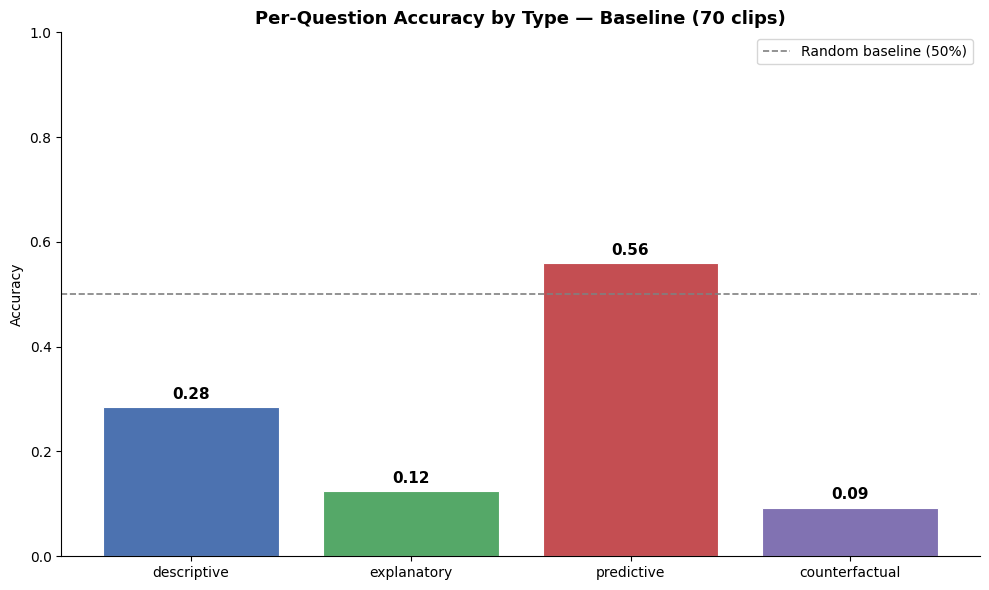

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/01_plot1_per_question_acc.jpg


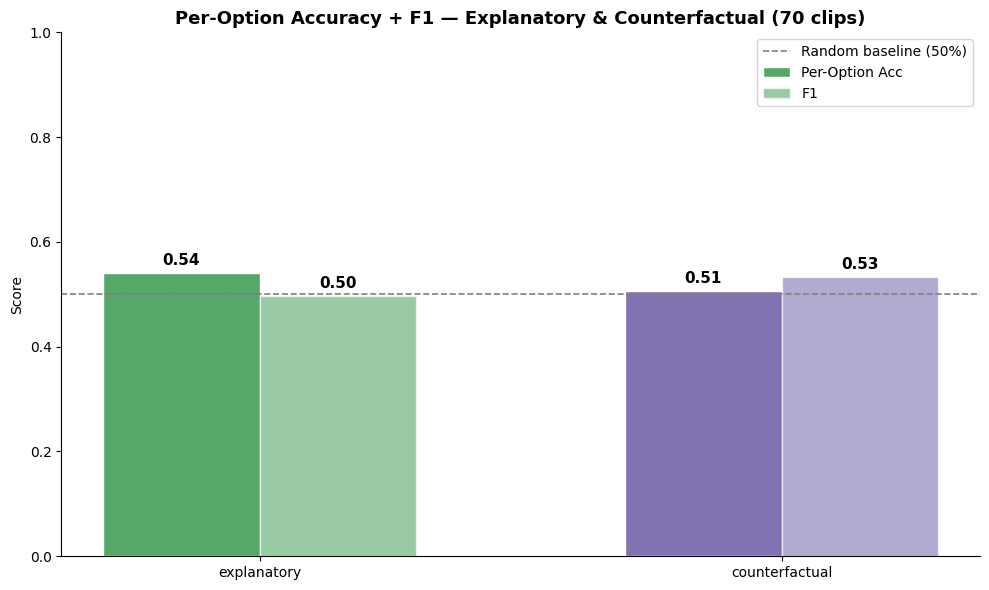

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/01_plot2_per_opt_f1.jpg


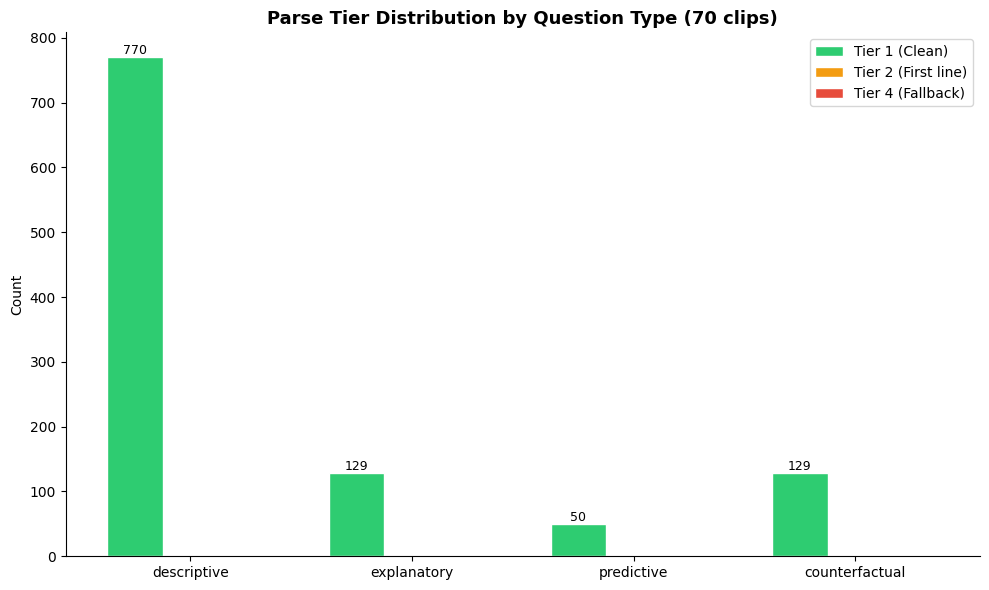

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/01_plot3_parse_tiers.jpg


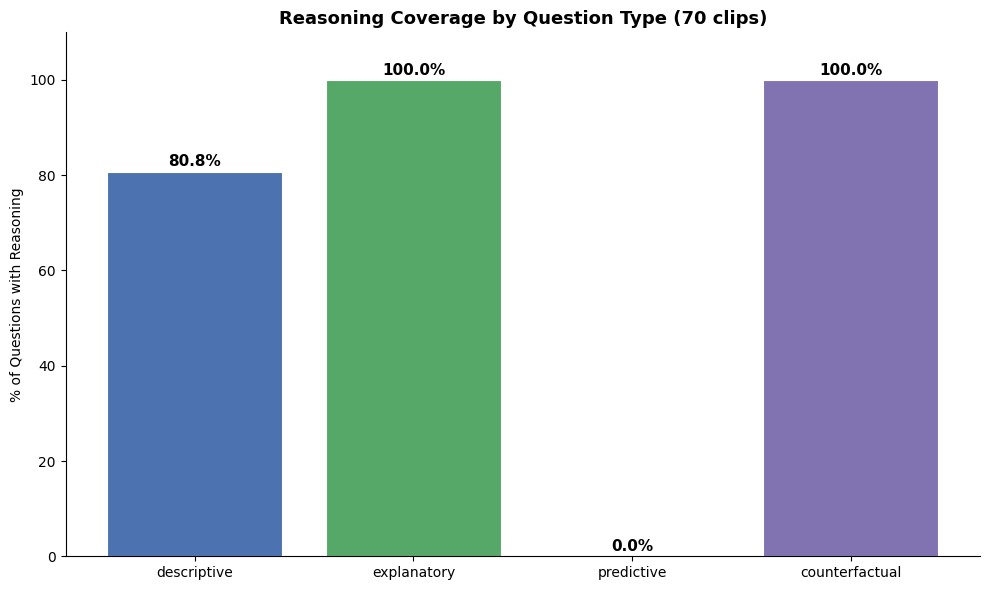

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/01_plot5_reasoning_coverage.jpg


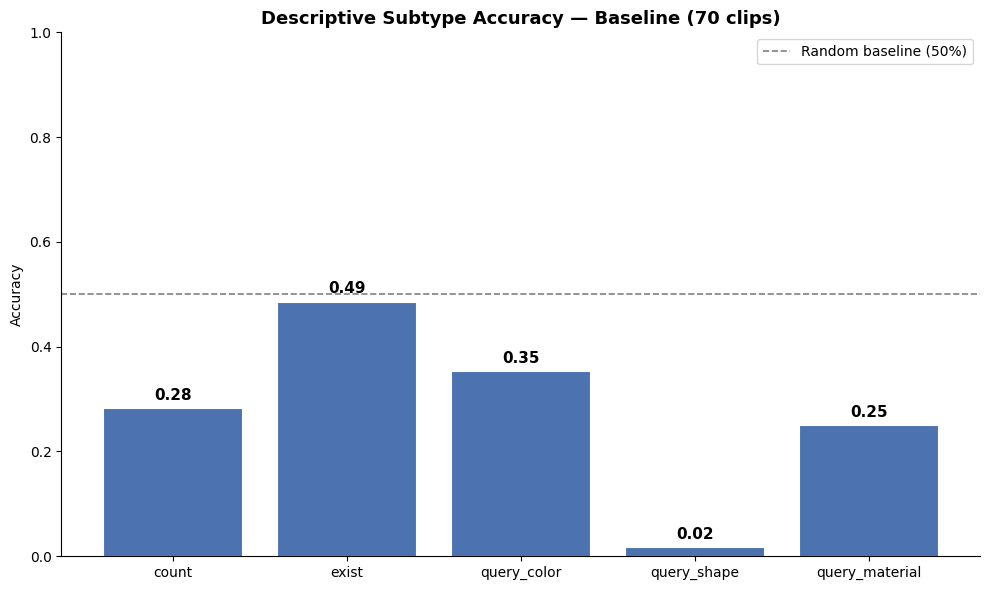

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/01_plot7_descriptive_subtypes.jpg


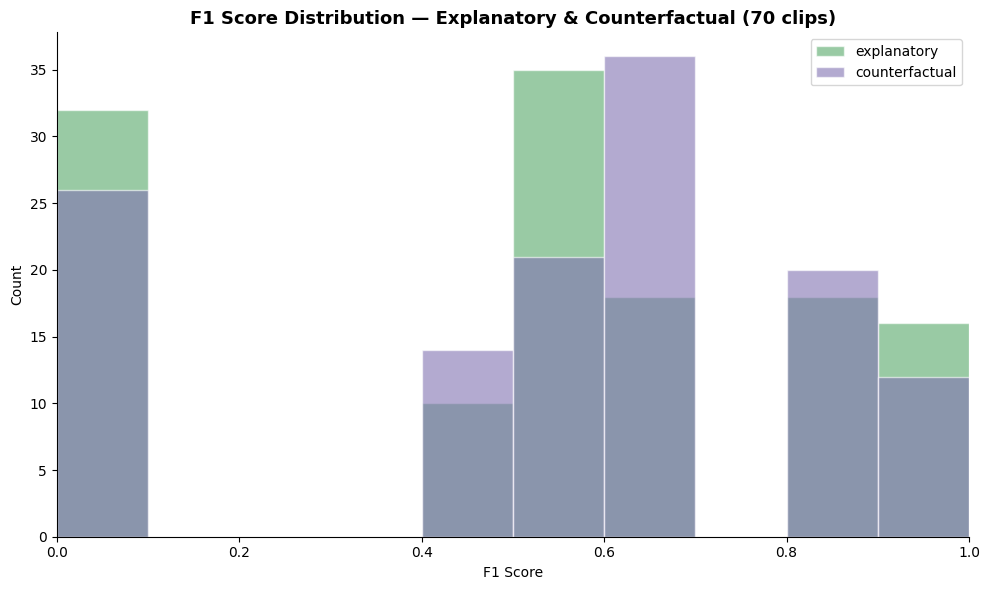

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/01_plot6_f1_distribution.jpg

All figures saved to figures/ on Drive.
Notebook 01 complete. Proceed to Notebook 00 to scale to 100 clips.


In [17]:
# ── Cell 9 — Report Figures ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import os
import json

Q_TYPES     = ['descriptive', 'explanatory', 'predictive', 'counterfactual']
SUBTYPES    = ['count', 'exist', 'query_color', 'query_shape', 'query_material']
COLORS      = {'descriptive': '#4C72B0', 'explanatory': '#55A868',
               'predictive': '#C44E52', 'counterfactual': '#8172B2'}
MULTI_TYPES = ['explanatory', 'counterfactual']

# ── Reload all baseline results ────────────────────────────────────────────────
all_results = []
for fname in sorted(os.listdir(OUT_DIR)):
    if fname.startswith('baseline_') and fname.endswith('.json') and 'error' not in fname:
        with open(os.path.join(OUT_DIR, fname), 'r') as f:
            all_results.append(json.load(f))

print(f"Loaded {len(all_results)} clip result files.")

# ── Aggregate all metrics ──────────────────────────────────────────────────────
agg = {qt: {'per_q_correct': 0, 'per_q_total': 0,
            'per_opt_correct': 0, 'per_opt_total': 0,
            'f1_scores': [], 'reasoning_count': 0,
            'tier_counts': {1: 0, 2: 0, 4: 0}}
       for qt in Q_TYPES}

subtype_agg = {st: {'correct': 0, 'total': 0} for st in SUBTYPES}

for clip in all_results:
    clip_id = clip['clip_id']
    for qr in clip.get('questions', []):
        qt = qr.get('question_type')
        if qt not in agg:
            continue

        # parse tier
        tier = qr.get('parse_tier')
        if tier in agg[qt]['tier_counts']:
            agg[qt]['tier_counts'][tier] += 1

        # reasoning coverage
        if qr.get('reasoning', '').strip():
            agg[qt]['reasoning_count'] += 1

        if qt in ('descriptive', 'predictive'):
            if qr.get('correct') is None:
                continue
            agg[qt]['per_q_total']   += 1
            agg[qt]['per_q_correct'] += int(qr['correct'])

            if qt == 'descriptive':
                qa_entry = qa_by_id.get(clip_id, {})
                matched  = next(
                    (q for q in qa_entry.get('questions', [])
                     if q['question_id'] == qr['question_id']),
                    None
                )
                if matched:
                    st = matched.get('question_subtype')
                    if st in subtype_agg:
                        subtype_agg[st]['total']   += 1
                        subtype_agg[st]['correct'] += int(qr['correct'])
        else:
            if qr.get('per_question_correct') is None:
                continue
            per_opt = qr.get('per_option_scores', [])
            agg[qt]['per_opt_total']   += len(per_opt)
            agg[qt]['per_opt_correct'] += sum(per_opt)
            agg[qt]['per_q_total']     += 1
            agg[qt]['per_q_correct']   += int(qr['per_question_correct'])
            agg[qt]['f1_scores'].append(qr.get('f1', 0.0))

# ── Compute metrics ────────────────────────────────────────────────────────────
per_q_acc   = {qt: (agg[qt]['per_q_correct'] / agg[qt]['per_q_total']
                    if agg[qt]['per_q_total'] > 0 else 0.0) for qt in Q_TYPES}
per_opt_acc = {qt: (agg[qt]['per_opt_correct'] / agg[qt]['per_opt_total']
                    if agg[qt]['per_opt_total'] > 0 else 0.0) for qt in MULTI_TYPES}
subtype_acc = {st: (subtype_agg[st]['correct'] / subtype_agg[st]['total']
                    if subtype_agg[st]['total'] > 0 else 0.0) for st in SUBTYPES}
reasoning_pct = {qt: (agg[qt]['reasoning_count'] / agg[qt]['per_q_total'] * 100
                      if agg[qt]['per_q_total'] > 0 else 0.0) for qt in Q_TYPES}

n_clips = len(all_results)

# ══════════════════════════════════════════════════════════════════════════════
# Plot 1 — Per-question accuracy all 4 types
# ══════════════════════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(10, 6))
vals     = [per_q_acc[qt] for qt in Q_TYPES]
colors   = [COLORS[qt] for qt in Q_TYPES]
bars     = ax1.bar(Q_TYPES, vals, color=colors, edgecolor='white', linewidth=0.8)
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Random baseline (50%)')
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title(f'Per-Question Accuracy by Type — Baseline ({n_clips} clips)',
              fontweight='bold', fontsize=13)
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.0)
ax1.legend(fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '01_plot1_per_question_acc.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ══════════════════════════════════════════════════════════════════════════════
# Plot 2 — Per-option accuracy + F1 for explanatory/counterfactual
# ══════════════════════════════════════════════════════════════════════════════
fig, ax2    = plt.subplots(figsize=(10, 6))
x           = np.arange(len(MULTI_TYPES))
width       = 0.3
per_opt_vals = [per_opt_acc[qt] for qt in MULTI_TYPES]
f1_vals      = [np.mean(agg[qt]['f1_scores']) if agg[qt]['f1_scores'] else 0.0
                for qt in MULTI_TYPES]
b1 = ax2.bar(x - width/2, per_opt_vals, width, label='Per-Option Acc',
             color=[COLORS[qt] for qt in MULTI_TYPES], edgecolor='white')
b2 = ax2.bar(x + width/2, f1_vals, width, label='F1',
             color=[COLORS[qt] for qt in MULTI_TYPES], edgecolor='white', alpha=0.6)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Random baseline (50%)')
for bar, val in zip(list(b1) + list(b2), per_opt_vals + f1_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title(f'Per-Option Accuracy + F1 — Explanatory & Counterfactual ({n_clips} clips)',
              fontweight='bold', fontsize=13)
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1.0)
ax2.set_xticks(x)
ax2.set_xticklabels(MULTI_TYPES)
ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '01_plot2_per_opt_f1.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ══════════════════════════════════════════════════════════════════════════════
# Plot 3 — Parse tier distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax3    = plt.subplots(figsize=(10, 6))
tiers       = [1, 2, 4]
tier_labels = ['Tier 1 (Clean)', 'Tier 2 (First line)', 'Tier 4 (Fallback)']
tier_colors = ['#2ecc71', '#f39c12', '#e74c3c']
x           = np.arange(len(Q_TYPES))
width       = 0.25
for i, (tier, tlabel, tcolor) in enumerate(zip(tiers, tier_labels, tier_colors)):
    vals = [agg[qt]['tier_counts'].get(tier, 0) for qt in Q_TYPES]
    bars = ax3.bar(x + (i - 1) * width, vals, width,
                   label=tlabel, color=tcolor, edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 0:
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     str(val), ha='center', va='bottom', fontsize=9)
ax3.set_title(f'Parse Tier Distribution by Question Type ({n_clips} clips)',
              fontweight='bold', fontsize=13)
ax3.set_ylabel('Count')
ax3.set_xticks(x)
ax3.set_xticklabels(Q_TYPES)
ax3.legend(fontsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '01_plot3_parse_tiers.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ══════════════════════════════════════════════════════════════════════════════
# Plot 5 — Reasoning coverage
# ══════════════════════════════════════════════════════════════════════════════
fig, ax5 = plt.subplots(figsize=(10, 6))
vals     = [reasoning_pct[qt] for qt in Q_TYPES]
colors   = [COLORS[qt] for qt in Q_TYPES]
bars     = ax5.bar(Q_TYPES, vals, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, vals):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax5.set_title(f'Reasoning Coverage by Question Type ({n_clips} clips)',
              fontweight='bold', fontsize=13)
ax5.set_ylabel('% of Questions with Reasoning')
ax5.set_ylim(0, 110)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '01_plot5_reasoning_coverage.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ══════════════════════════════════════════════════════════════════════════════
# Plot 7 — Descriptive subtype accuracy
# ══════════════════════════════════════════════════════════════════════════════
fig, ax7 = plt.subplots(figsize=(10, 6))
vals     = [subtype_acc[st] for st in SUBTYPES]
bars     = ax7.bar(SUBTYPES, vals, color='#4C72B0', edgecolor='white', linewidth=0.8)
ax7.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Random baseline (50%)')
for bar, val in zip(bars, vals):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax7.set_title(f'Descriptive Subtype Accuracy — Baseline ({n_clips} clips)',
              fontweight='bold', fontsize=13)
ax7.set_ylabel('Accuracy')
ax7.set_ylim(0, 1.0)
ax7.legend(fontsize=10)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '01_plot7_descriptive_subtypes.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

# ══════════════════════════════════════════════════════════════════════════════
# Plot 6 — F1 score distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax6 = plt.subplots(figsize=(10, 6))
for qt in MULTI_TYPES:
    scores = agg[qt]['f1_scores']
    if scores:
        ax6.hist(scores, bins=10, range=(0, 1), alpha=0.6,
                 label=qt, color=COLORS[qt], edgecolor='white')
ax6.set_title(f'F1 Score Distribution — Explanatory & Counterfactual ({n_clips} clips)',
              fontweight='bold', fontsize=13)
ax6.set_xlabel('F1 Score')
ax6.set_ylabel('Count')
ax6.set_xlim(0, 1.0)
ax6.legend(fontsize=10)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '01_plot6_f1_distribution.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

print("\nAll figures saved to figures/ on Drive.")
print("Notebook 01 complete. Proceed to Notebook 00 to scale to 100 clips.")

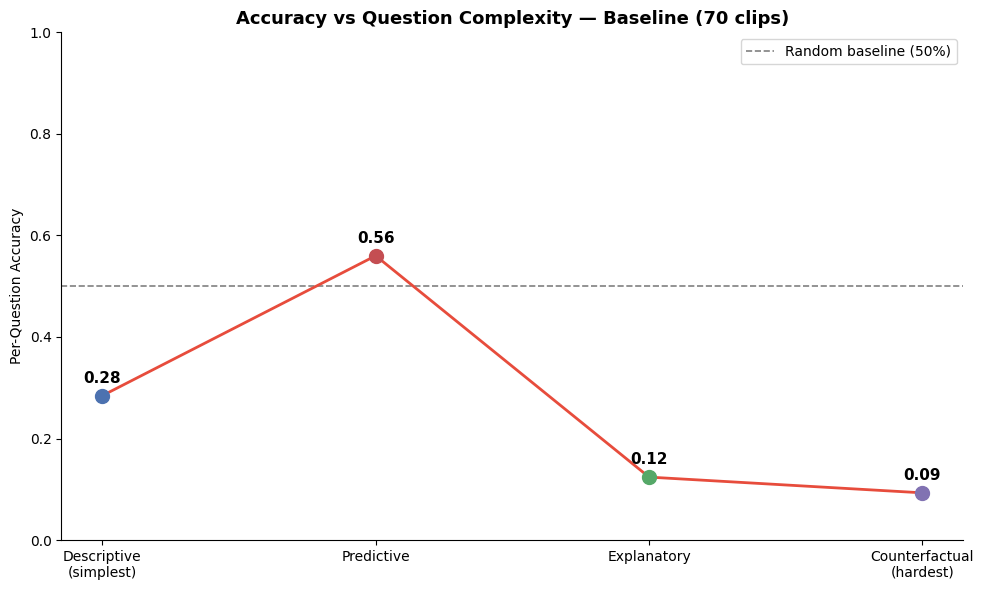

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/01_plot8_accuracy_vs_complexity.jpg


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot 8 — Accuracy vs complexity curve
# ══════════════════════════════════════════════════════════════════════════════
fig, ax8 = plt.subplots(figsize=(10, 6))
complexity_order = ['descriptive', 'predictive', 'explanatory', 'counterfactual']
vals   = [per_q_acc[qt] for qt in complexity_order]
colors = [COLORS[qt] for qt in complexity_order]
ax8.plot(range(len(complexity_order)), vals, 'o-',
         color='#e74c3c', linewidth=2, markersize=8, zorder=3)
for i, (val, qt) in enumerate(zip(vals, complexity_order)):
    ax8.scatter(i, val, color=COLORS[qt], s=100, zorder=4)
    ax8.text(i, val + 0.02, f'{val:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax8.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Random baseline (50%)')
ax8.set_title(f'Accuracy vs Question Complexity — Baseline ({n_clips} clips)',
              fontweight='bold', fontsize=13)
ax8.set_ylabel('Per-Question Accuracy')
ax8.set_ylim(0, 1.0)
ax8.set_xticks(range(len(complexity_order)))
ax8.set_xticklabels(['Descriptive\n(simplest)', 'Predictive',
                     'Explanatory', 'Counterfactual\n(hardest)'])
ax8.legend(fontsize=10)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '01_plot8_accuracy_vs_complexity.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")

---